#### Simulations Parameter 

In [1]:
#Libarys
from utils import simulation, save_results, plot_pred_bias 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings("ignore", message="findfont: Font family")

In [2]:
# Sim settings
n = int(5000.8/0.7)

train_models= True
ijk_jahn_calc= True
ijk_wager_calc= True
print('n_train: ',int(n*0.7))    

n_train:  5000


In [3]:
n_sim = 1000
B_RF = int(n * 0.7 )
seed = 42
n_covariates = 4
boot_calc= [False, 200 ]
ijk_butt_calc= False
jk_wager_calc= False

In [4]:
# data generation parameters and RF parameters
X_pred_point = pd.DataFrame({'X_1': [0], 'X_2': [1], 'X_3': [80], 'X_4': [40]})
data_generation_parameter_1 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':   22_080       , 
                                    'rate_censoring':       0.00321    , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point}  

data_generation_parameter_3 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':  18_900        , 
                                    'rate_censoring':       0.01125   , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point }

data_generation_parameter_5 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':  15120        , 
                                    'rate_censoring':       0.023293   , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point }


params_rf =         {   'n_estimators':B_RF,                        
                        'max_depth':4,
                        'min_samples_split':5,
                        'max_features': 'log2',
                        'random_state':  seed,
                        'weighted_bootstrapping': True, } 

#### Start Simulation

In [5]:
# Run simulations
dp = data_generation_parameter_1
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk_u_butt_var = np.zeros(n_sim)
    ijk_u2_butt_var = np.zeros(n_sim)
    ijk_jahn_var = np.zeros(n_sim)
    ijk_u_jahn_var = np.zeros(n_sim)
    ijk_u2_jahn_var = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_u_wager_var = np.zeros(n_sim)
    jk_wager_var = np.zeros(n_sim)
    jk_u_wager_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)

    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)

    futures = [ executor.submit(  
                                  simulation,
                                  seed=seed+i,
                                  data_generation_parameter=dp,
                                  params_rf=params_rf,
                                  train_models=train_models,
                                  ijk_wager_calc=ijk_wager_calc,
                                  ijk_butt_calc=ijk_butt_calc,
                                  ijk_jahn_calc=ijk_jahn_calc,
                                  jk_wager_calc=jk_wager_calc,
                                  boot_calc=boot_calc,)
                for i in range(n_sim) ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_butt_var, _ijk_jahn_var, _ijk_wager_var, _jk_wager_var, _boot_var, _survived_stats_train,_survived_stats_test   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]

        # Standard Deviation Estimates
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk_u_butt_var[i] = _ijk_butt_var[1]
        ijk_u2_butt_var[i] =  _ijk_butt_var[2]

        ijk_jahn_var[i] = _ijk_jahn_var[0]
        ijk_u_jahn_var[i] = _ijk_jahn_var[1]
        ijk_u2_jahn_var[i] = _ijk_jahn_var[2]

        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_u_wager_var[i] = _ijk_wager_var[1]

        jk_wager_var[i] = _jk_wager_var[0]
        jk_u_wager_var[i] = _jk_wager_var[1]

        boot_var[i] = _boot_var

results1 = pd.DataFrame({'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train,
                        'portion_zero_weights_test': portion_zero_weights_test, 'portion_seen_events_test': portion_seen_events_test,
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'wb_pred': wb_pred, 'rf_pred': rf_pred, 
                        'ijk_butt_var': ijk_butt_var, 'ijk_u_butt_var': ijk_u_butt_var, 'ijk_u2_butt_var': ijk_u2_butt_var,
                        'ijk_jahn_var': ijk_jahn_var, 'ijk_u_jahn_var': ijk_u_jahn_var, 'ijk_u2_jahn_var': ijk_u2_jahn_var,
                        'ijk_wager_var': ijk_wager_var, 'ijk_u_wager_var': ijk_u_wager_var, 'jk_wager_var': jk_wager_var, 'jk_u_wager_var': jk_u_wager_var,
                        'boot_var': boot_var, 
                        })


dp = data_generation_parameter_3
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk_u_butt_var = np.zeros(n_sim)
    ijk_u2_butt_var = np.zeros(n_sim)
    ijk_jahn_var = np.zeros(n_sim)
    ijk_u_jahn_var = np.zeros(n_sim)
    ijk_u2_jahn_var = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_u_wager_var = np.zeros(n_sim)
    jk_wager_var = np.zeros(n_sim)
    jk_u_wager_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)

    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)

    futures = [ executor.submit(  
                                  simulation,
                                  seed=seed+i,
                                  data_generation_parameter=dp,
                                  params_rf=params_rf,
                                  train_models=train_models,
                                  ijk_wager_calc=ijk_wager_calc,
                                  ijk_butt_calc=ijk_butt_calc,
                                  ijk_jahn_calc=ijk_jahn_calc,
                                  jk_wager_calc=jk_wager_calc,
                                  boot_calc=boot_calc,)
                for i in range(n_sim) ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_butt_var, _ijk_jahn_var, _ijk_wager_var, _jk_wager_var, _boot_var, _survived_stats_train,_survived_stats_test   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]

        # Standard Deviation Estimates
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk_u_butt_var[i] = _ijk_butt_var[1]
        ijk_u2_butt_var[i] =  _ijk_butt_var[2]

        ijk_jahn_var[i] = _ijk_jahn_var[0]
        ijk_u_jahn_var[i] = _ijk_jahn_var[1]
        ijk_u2_jahn_var[i] = _ijk_jahn_var[2]

        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_u_wager_var[i] = _ijk_wager_var[1]

        jk_wager_var[i] = _jk_wager_var[0]
        jk_u_wager_var[i] = _jk_wager_var[1]

        boot_var[i] = _boot_var

results3 = pd.DataFrame({'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train,
                        'portion_zero_weights_test': portion_zero_weights_test, 'portion_seen_events_test': portion_seen_events_test,
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'wb_pred': wb_pred, 'rf_pred': rf_pred, 
                        'ijk_butt_var': ijk_butt_var, 'ijk_u_butt_var': ijk_u_butt_var, 'ijk_u2_butt_var': ijk_u2_butt_var,
                        'ijk_jahn_var': ijk_jahn_var, 'ijk_u_jahn_var': ijk_u_jahn_var, 'ijk_u2_jahn_var': ijk_u2_jahn_var,
                        'ijk_wager_var': ijk_wager_var, 'ijk_u_wager_var': ijk_u_wager_var, 'jk_wager_var': jk_wager_var, 'jk_u_wager_var': jk_u_wager_var,
                        'boot_var': boot_var, 
                        })


dp = data_generation_parameter_5
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk_u_butt_var = np.zeros(n_sim)
    ijk_u2_butt_var = np.zeros(n_sim)
    ijk_jahn_var = np.zeros(n_sim)
    ijk_u_jahn_var = np.zeros(n_sim)
    ijk_u2_jahn_var = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_u_wager_var = np.zeros(n_sim)
    jk_wager_var = np.zeros(n_sim)
    jk_u_wager_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)

    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)

    futures = [ executor.submit(  
                                  simulation,
                                  seed=seed+i,
                                  data_generation_parameter=dp,
                                  params_rf=params_rf,
                                  train_models=train_models,
                                  ijk_wager_calc=ijk_wager_calc,
                                  ijk_butt_calc=ijk_butt_calc,
                                  ijk_jahn_calc=ijk_jahn_calc,
                                  jk_wager_calc=jk_wager_calc,
                                  boot_calc=boot_calc,)
                for i in range(n_sim) ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_butt_var, _ijk_jahn_var, _ijk_wager_var, _jk_wager_var, _boot_var, _survived_stats_train,_survived_stats_test   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]

        # Standard Deviation Estimates
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk_u_butt_var[i] = _ijk_butt_var[1]
        ijk_u2_butt_var[i] =  _ijk_butt_var[2]

        ijk_jahn_var[i] = _ijk_jahn_var[0]
        ijk_u_jahn_var[i] = _ijk_jahn_var[1]
        ijk_u2_jahn_var[i] = _ijk_jahn_var[2]

        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_u_wager_var[i] = _ijk_wager_var[1]

        jk_wager_var[i] = _jk_wager_var[0]
        jk_u_wager_var[i] = _jk_wager_var[1]

        boot_var[i] = _boot_var

results5 = pd.DataFrame({'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train,
                        'portion_zero_weights_test': portion_zero_weights_test, 'portion_seen_events_test': portion_seen_events_test,
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'wb_pred': wb_pred, 'rf_pred': rf_pred, 
                        'ijk_butt_var': ijk_butt_var, 'ijk_u_butt_var': ijk_u_butt_var, 'ijk_u2_butt_var': ijk_u2_butt_var,
                        'ijk_jahn_var': ijk_jahn_var, 'ijk_u_jahn_var': ijk_u_jahn_var, 'ijk_u2_jahn_var': ijk_u2_jahn_var,
                        'ijk_wager_var': ijk_wager_var, 'ijk_u_wager_var': ijk_u_wager_var, 'jk_wager_var': jk_wager_var, 'jk_u_wager_var': jk_u_wager_var,
                        'boot_var': boot_var, 
                        })

exp_save_path = save_results(n=n, n_covariates=n_covariates, B_RF=B_RF, boot_calc=boot_calc, seed=seed, results1=results1, results3=results3, results5=results5,
             data_generation_parameter_1=data_generation_parameter_1, data_generation_parameter_3=data_generation_parameter_3, 
             data_generation_parameter_5=data_generation_parameter_5, params_rf=params_rf)

print(exp_save_path)

Simulations: 100%|██████████| 1000/1000 [37:37<00:00,  2.26s/simulation] 


c:\Users\rehan\OneDrive\00_TO-DO\paper_review\Masterarbeit_Butt\Paper_abgabe\simulation_study/results/(n_train)5000__(B_RF)5000__(B_1)200__(n_sim)1000__(seed)42__4kovariates_test_boot/121.8996888


#### Plots

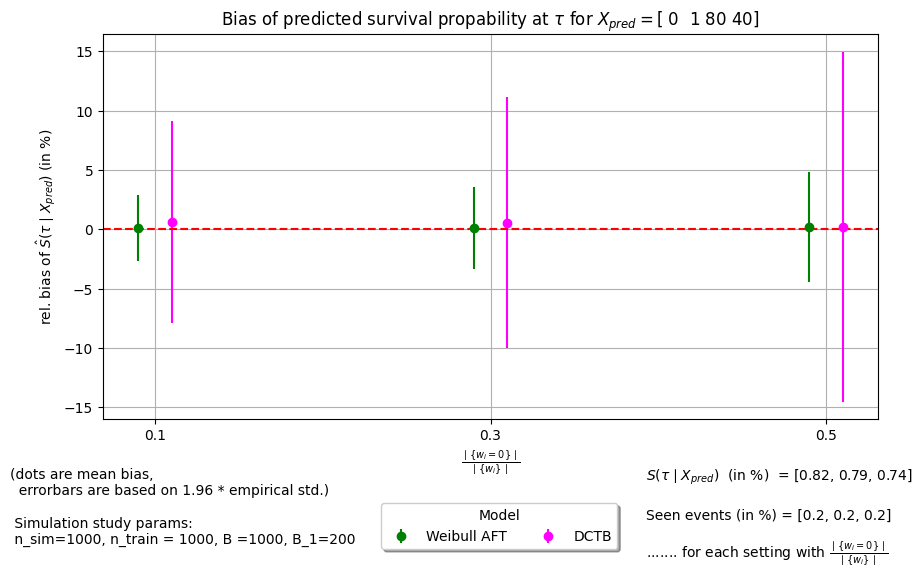

In [6]:
from utils import save_results, plot_pred_bias #, plot_var_bias, plot_var_bias_without_u2
exp_save_path = r'C:\Users\rehan\OneDrive\00_TO-DO\paper_review\Masterarbeit_Butt\Paper_abgabe\simulation_study\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates\121.90058'
#exp_save_path2 = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper_abgabe\simulation_study\results\(n_train)2000__(B_RF)2000__(B_1)200__(n_sim)1000__(seed)42__4kovariates_test\121.900006'
#plot_var_bias_without_u2(exp_save_path,-60,410)
plot_pred_bias(exp_save_path)
#plot_var_bias(exp_save_path)
